In [1]:
import pandas as pd
import geopandas as gpd

survey_gdf = gpd.read_file('Nyandarua.geojson')
survey_gdf.head(10)

,fid,Farming_type,crop_a,crop_b,crop_c,crop_d,crop_e,sub-county,county,date_of_collection,crop_growth_stage,geometry
0,26,mono_cultu,Maize,NaN,None,None,None,Ol Jorok,Nyandarua,2024-07-12,Tillering/Booting,"POLYGON ((36.26121 -0.10093, 36.26146 -0.10107..."
1,27,mono_cultu,Maize,NaN,None,None,None,Ol Jorok,Nyandarua,2024-07-12,Tillering/Booting,"POLYGON ((36.2938 -0.03277, 36.29373 -0.03292,..."
2,28,mono_cultu,Maize,NaN,None,None,None,Ol Jorok,Nyandarua,2024-07-12,Tillering/Booting,"POLYGON ((36.29593 -0.0282, 36.29609 -0.02826,..."
3,29,mono_cultu,Maize,NaN,None,None,None,Ol Jorok,Nyandarua,2024-07-12,Tillering/Booting,"POLYGON ((36.29797 -0.02193, 36.29807 -0.02177..."
4,30,mono_cultu,Maize,NaN,None,None,None,Ol Jorok,Nyandarua,2024-07-12,Tillering/Booting,"POLYGON ((36.30828 -0.01573, 36.3094 -0.01565,..."
5,31,mono_cultu,Maize,NaN,None,None,None,Ol Jorok,Nyandarua,2024-07-12,Tillering/Booting,"POLYGON ((36.34524 -0.00786, 36.34552 -0.00781..."
6,32,mono_cultu,Maize,NaN,None,None,None,Ol Jorok,Nyandarua,2024-07-12,Tillering/Booting,"POLYGON ((36.34546 0.00653, 36.34573 0.00652, ..."
7,33,mono_cultu,Maize,NaN,None,None,None,Ol Jorok,Nyandarua,2024-07-12,Tillering/Booting,"POLYGON ((36.31991 -0.01231, 36.32001 -0.01218..."
8,34,mono_cultu,Maize,NaN,None,None,None,Ol Jorok,Nyandarua,2024-07-12,Tillering/Booting,"POLYGON ((36.3558 -0.03391, 36.35656 -0.03385,..."
9,35,mono_cultu,Maize,NaN,None,None,None,Ol Jorok,Nyandarua,2024-07-12,Tillering/Booting,"POLYGON ((36.36262 -0.03353, 36.36331 -0.03356..."


In [2]:
# import ee
# import os
# import shutil

# # Clear cached Earth Engine credentials to force fresh authentication
# ee_config_dir = os.path.expanduser('~/.config/earthengine')
# if os.path.exists(ee_config_dir):
#     shutil.rmtree(ee_config_dir)
#     print("✅ Cleared cached Earth Engine credentials")

# # Authenticate with explicit scopes for Drive exports (no billing required)
# # Scopes include Drive storage for exports and Earth Engine access
# scopes = [
#     'https://www.googleapis.com/auth/earthengine',
#     'https://www.googleapis.com/auth/drive'  # Required for toDrive() exports
# ]

# # Force interactive authentication
# ee.Authenticate(scopes=scopes)
# print("✅ Authenticated with Earth Engine (Drive scope included)")

# # Initialize with high-volume endpoint for batch exports
# ee.Initialize(project='980132291005', opt_url='https://earthengine-highvolume.googleapis.com')
# print("✅ Earth Engine initialized with high-volume endpoint")

In [3]:
import ee

try:
        ee.Initialize()
except Exception as e:
        ee.Authenticate()
        ee.Initialize()

In [4]:
import geopandas as gpd
import geemap
import ee

# Authenticate and initialize Google Earth Engine
# ee.Authenticate()
# ee.Initialize()

# Load the GeoJSON file into a GeoDataFrame
plot = gpd.read_file('Nyandarua.geojson')

# Convert the GeoDataFrame to a Google Earth Engine object
ee_plot = geemap.geopandas_to_ee(plot)

# Define the center of the map (latitude, longitude)
center_lat = -0.289  
center_lon = 36.439  

# Create a map centered at the specified location
map_plot = geemap.Map(center=[center_lat, center_lon], zoom=15)

# Add a satellite basemap
map_plot.add_basemap('SATELLITE')

# Add the polygon layer to the map
map_plot.addLayer(ee_plot, {'color': 'a4c639'}, 'Survey Plots', opacity=0.8)
# 

# Display the map
map_plot

Map(center=[-0.289, 36.439], controls=(WidgetControl(options=['position', 'transparent_bg'], position='toprigh…

In [5]:
# Cherck the coordinate reference system (CRS) of the GeoDataFrame
survey_gdf_crs = plot.crs
survey_gdf_crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [6]:
# 
survey_gdf = plot.to_crs(4326)
survey_gdf.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [7]:
#define names which identify maize
maize_name = ["Maize"]
# identify True/False whether crop code columns have maize codes; sum these True/False values to identify if any contained maize
survey_gdf['maize_pos'] = survey_gdf.loc[:,('crop_a','crop_b','crop_c','crop_d','crop_e')].isin(maize_name).sum(axis=1)
survey_gdf

,fid,Farming_type,crop_a,crop_b,crop_c,crop_d,crop_e,sub-county,county,date_of_collection,crop_growth_stage,geometry,maize_pos
0,26,mono_cultu,Maize,NaN,None,None,None,Ol Jorok,Nyandarua,2024-07-12,Tillering/Booting,"POLYGON ((36.26121 -0.10093, 36.26146 -0.10107...",1
1,27,mono_cultu,Maize,NaN,None,None,None,Ol Jorok,Nyandarua,2024-07-12,Tillering/Booting,"POLYGON ((36.2938 -0.03277, 36.29373 -0.03292,...",1
2,28,mono_cultu,Maize,NaN,None,None,None,Ol Jorok,Nyandarua,2024-07-12,Tillering/Booting,"POLYGON ((36.29593 -0.0282, 36.29609 -0.02826,...",1
3,29,mono_cultu,Maize,NaN,None,None,None,Ol Jorok,Nyandarua,2024-07-12,Tillering/Booting,"POLYGON ((36.29797 -0.02193, 36.29807 -0.02177...",1
4,30,mono_cultu,Maize,NaN,None,None,None,Ol Jorok,Nyandarua,2024-07-12,Tillering/Booting,"POLYGON ((36.30828 -0.01573, 36.3094 -0.01565,...",1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
156,182,mono_cultu,Maize,NaN,None,None,None,Ol Kalou,Nyandarua,2024-07-12,Tillering/Booting,"POLYGON ((36.37872 -0.21638, 36.37915 -0.21575...",1
157,183,mono_cultu,Maize,NaN,None,None,None,Ol Kalou,Nyandarua,2024-07-12,Tillering/Booting,"POLYGON ((36.3753 -0.23204, 36.37518 -0.23242,...",1
158,184,mono_cultu,Maize,NaN,None,None,None,Ol Kalou,Nyandarua,2024-07-12,Tillering/Booting,"POLYGON ((36.38649 -0.26525, 36.38738 -0.26484...",1
159,185,mono_cultu,Maize,NaN,None,None,None,Ol Kalou,Nyandarua,2024-07-12,Tillering/Booting,"POLYGON ((36.40524 -0.25278, 36.40575 -0.25306...",1


## Obtain Nyandarua County Boundary from GAUL/2015/Level 2 data from Google Earth Engine 

In [8]:
# Obtain level2 boundaries, filter for Nyandarua, convert to geometry
nyandarua_geom = ee.Feature(ee.FeatureCollection("FAO/GAUL/2015/level2").filter(ee.Filter.eq('ADM2_NAME', 'Nyandarua')).geometry())

# Visualize the area of Nyandarua we created
center_lat = -0.289 
center_lon = 36.439 

map_nyandarua = geemap.Map(center=[center_lat,center_lon],zoom=10)
map_nyandarua.add_basemap('SATELLITE')
map_nyandarua.addLayer(nyandarua_geom,vis_params={'color':'a4c639'},opacity=0.9, name='Nyandarua Boundary')
# Add the polygon layer to the map
map_nyandarua.addLayer(ee_plot, {'color': 'b4c689'}, 'Survey Plots', opacity=0.8)
map_nyandarua


Map(center=[-0.289, 36.439], controls=(WidgetControl(options=['position', 'transparent_bg'], position='toprigh…

### Obtain Plot area from the Geometry

In [9]:
# Project to appropriate CRS for area calculation (e.g., UTM)
survey_gdf.to_crs(epsg=32636, inplace=True)  # UTM zone 36N for Kenya
survey_gdf.crs

<Projected CRS: EPSG:32636>
Name: WGS 84 / UTM zone 36N
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Between 30°E and 36°E, northern hemisphere between equator and 84°N, onshore and offshore. Belarus. Cyprus. Egypt. Ethiopia. Finland. Israel. Jordan. Kenya. Lebanon. Moldova. Norway. Russian Federation. Saudi Arabia. Sudan. Syria. Türkiye (Turkey). Uganda. Ukraine.
- bounds: (30.0, 0.0, 36.0, 84.0)
Coordinate Operation:
- name: UTM zone 36N
- method: Transverse Mercator
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [10]:
# Calculate plot area in square meters and convert to acres
survey_gdf['plot_area_acres'] = survey_gdf.area * 0.0002471054 
survey_gdf.head()


,fid,Farming_type,crop_a,crop_b,crop_c,crop_d,crop_e,sub-county,county,date_of_collection,crop_growth_stage,geometry,maize_pos,plot_area_acres
0,26,mono_cultu,Maize,NaN,None,None,None,Ol Jorok,Nyandarua,2024-07-12,Tillering/Booting,"POLYGON ((863087.965 -11173.466, 863116.199 -1...",1,0.243271
1,27,mono_cultu,Maize,NaN,None,None,None,Ol Jorok,Nyandarua,2024-07-12,Tillering/Booting,"POLYGON ((866720.923 -3627.828, 866712.829 -36...",1,0.058804
2,28,mono_cultu,Maize,NaN,None,None,None,Ol Jorok,Nyandarua,2024-07-12,Tillering/Booting,"POLYGON ((866958.614 -3122.395, 866976.059 -31...",1,0.097300
3,29,mono_cultu,Maize,NaN,None,None,None,Ol Jorok,Nyandarua,2024-07-12,Tillering/Booting,"POLYGON ((867185.425 -2428.172, 867197.296 -24...",1,0.217708
4,30,mono_cultu,Maize,NaN,None,None,None,Ol Jorok,Nyandarua,2024-07-12,Tillering/Booting,"POLYGON ((868335.243 -1741.822, 868459.343 -17...",1,3.602666


In [11]:
# Convert the GeoDataFrame back to WGS84 (EPSG:4326) for visualization
survey_gdf = survey_gdf.to_crs(epsg=4326)
survey_gdf.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

## Using Azzari's modules to pull the Sentinel -2 data, mask clouds and calculate various indices 
* Clone the repo by pasting this in your command line ```git clone https://github.com/shrutijain90/eetc.git``` 

In [12]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd() / "eetc"))

# Print the current working directory to verify the path
# print("Current working directory:", Path.cwd())

In [13]:
# Import Azzari et al code 
from eetc import gee_tools
import gee_tools.datasources.sentinel2_2a as s2_2a

In [14]:
# Obtain ImageCollection for specified area and dates with vegetation indices (addVIs) and cloud masks defined (addCloudMasks)
# code from Azzari et al.
s2coll_2a = s2_2a.Sentinel2SR(nyandarua_geom.geometry(), 
                            start_date = ee.Date('2024-03-01'), 
                            end_date = ee.Date('2024-08-31'), 
                            addVIs=True, 
                            addCloudMasks=False).get_img_coll()

s2coll_2a.first()

In [15]:
# for band in s2coll_2a.first().getInfo()['bands']:
#     print(band['id'])

## Choose Bands of interest and Mask out clouds

In [16]:
# Use Azzari et al's function to mask clouds
def maskClouds_sr(img, bandnames):
    scl = img.select(['SCL'])
    clear = scl.updateMask(scl.eq(4) or (scl.eq(5)))
    img = img.updateMask(clear)
    return img.select(bandnames)

In [17]:
# Define the bandames in the S2-2A data which we want to keep
bandnames = ['AEROS','BLUE','GREEN','RED','RDED1','RDED2','RDED3','NIR','RDED4','VAPOR','SWIR1','SWIR2','NBR1','NDTI','GCVI','NDVI','SNDVI']
# Mask clouds using the function above
s2coll_2a = s2coll_2a.map(lambda img: maskClouds_sr(img, bandnames))

In [18]:
for band in s2coll_2a.first().getInfo()['bands']:
    print(band['id'])

AEROS
BLUE
GREEN
RED
RDED1
RDED2
RDED3
NIR
RDED4
VAPOR
SWIR1
SWIR2
NBR1
NDTI
GCVI
NDVI
SNDVI


### Produce GCVI for nyandarua

In [19]:
# this is not a real plot from any survey data; it was randomly selected for demonstration
center_lat = -0.289 
center_lon = 36.439 

gcvi_samp = s2coll_2a.select('GCVI').filterBounds(ee.Geometry.Point([center_lon,center_lat]).buffer(2000))

map_point_g = geemap.Map(center=[center_lat,center_lon],zoom=11)
map_point_g.add_basemap('SATELLITE')
# set color range to use for GCVI levels: black is lowest, beginning at 0, through green as the highest, ending at 5
gcvi_params = {'min': 0, 'max': 5, 'palette': ['black','red', 'orange', 'yellow', 'green']}

map_point_g.addLayer(gcvi_samp, gcvi_params)
map_point_g

Map(center=[-0.289, 36.439], controls=(WidgetControl(options=['position', 'transparent_bg'], position='toprigh…

In [20]:
# obtain extended timeframe for S2 SA imagery, if desired
s2coll_2a_ext = s2_2a.Sentinel2SR(nyandarua_geom.geometry(), start_date = ee.Date('2024-03-01'), end_date = ee.Date('2024-08-31'), addVIs=True, addCloudMasks=False).get_img_coll()
# Define the bandames in the S2-2A data which we want to keep
bandnames = ['AEROS','BLUE','GREEN','RED','RDED1','RDED2','RDED3','NIR','RDED4','VAPOR','SWIR1','SWIR2','NBR1','NDTI','GCVI','NDVI','SNDVI']
# Mask clouds
s2coll_2a_ext = s2coll_2a_ext.map(lambda img: maskClouds_sr(img, bandnames))

In [21]:
# create point_g as earth engine point of interest for which to pull GCVI values
# this is not a real plot from any survey data; it was randomly selected for demonstration
ee_point_g = ee.Geometry.Point(36.381935,-0.309634)

In [22]:
map_point_g = geemap.Map(center=[-0.309634, 36.381935],zoom=14)

map_point_g.add_basemap('SATELLITE')
map_point_g.addLayer(ee_point_g, vis_params={'color':'a4c639'})
# Add the GCVI layer for the point of interest
gcvi_samp = s2coll_2a.select('GCVI').filterBounds(ee.Geometry.Point([36.381935,-0.309634]).buffer(2000))
gcvi_params = {'min': 0, 'max': 5, 'palette': ['black','red', 'orange', 'yellow', 'green']}
map_point_g.addLayer(gcvi_samp, gcvi_params, name='GCVI')
# # Add the 
map_point_g

Map(center=[-0.309634, 36.381935], controls=(WidgetControl(options=['position', 'transparent_bg'], position='t…

In [23]:
# create list of all image timestamps
def create_timestamp_list(imgcoll): 
    """
    Create list of timestamps for all Images in ImageCollection
    Inputs:
        imgcoll (ImageCollection): ImageCollection to be processed
    Returns (list): list of all timestamps of Images
    """
    ts_list = ee.List(imgcoll \
    .aggregate_array('system:time_start')) \
    .map(lambda time_start: 
         ee.Date(time_start).format('Y-MM-dd HH:mm:ss')
    ) \
    .getInfo()

    return ts_list

# create list of all image indices; attach suffix to match
# band name format which will be applied once .toBands() is applied
def create_band_list(imgcoll, suffix):
    """
    Create list of all indices for Images in ImageCollection
    Inputs:
        imgcoll (ImageCollection): ImageCollection to be processed
        suffix (str): string in the form '_' + bandname (eg, '_GCVI')
            to add to each Image system:index. This is done to match the
            naming convention which will be used in .toBands() to convert
            ImageCollection into single Image
    Returns (list): list of all bands which will be in Image
        created from ImageCollection.toBands()
    """
    band_list = ee.List(imgcoll \
    .aggregate_array('system:index')) \
    .getInfo()

    band_list = [band + suffix for band in band_list]

    return band_list

def sample_lists(list, every_x):
    """
    Reduces list size to every x-th item, maintaining temporal order
    Inputs:
        list (list): list of dates or bands to sample
        every_x (int): specifies how many items from list to keep
    Returns (list): sample of original list
    """
    # create list of every xth item from list
    list_samp = list[0::every_x]
    
    return list_samp

# create dataframe with pixel values and timestamps
def extract_pixel_vals_dates(imgcoll, band, ee_point, \
    band_list=None, time_list=None, sample=None):
    """
    Extract the pixel values and timestamp for the specified band of 
        every image in an ImageCollection.
    Inputs:
        imgcoll (ImageCollection): ImageCollection containing band of interest
            over time range
        band (str): name of band to find values for from ImageCollection
        ee_point (ee.Geometry.Point): point location for which to find band values
        band_list (list or None): if same ImageCollection has already been processed,
            can use created band_list of unmasked Images to avoid re-checking all
            Images for clouds. If None, band_list is created as list of every band in
            the Image created from original ImageCollection
        time_list (list or None): if same ImageCollection has already been processed,
            can use created time_list of unmasked Images to avoid re-checking all
            Images for clouds. If None, time_list is created as list of timestamp
            for every band in the Image created from original ImageCollection
        sample (int or None): if provided, sample ImageCollection Images to only
            process every x-th image. If None, full ImageCollection is processed.
    Returns (DataFrame): Pandas DataFrame containing timestamp, band values, and band_ids
        for each unmasked pixel
    """

    # extract band of interest from image collection
    print('selecting band of interest', band,'from imagecollection')
    band_coll = imgcoll.select(band)

    # filter imagecollection for only images containing point
    print('filtering for only images containing point')
    point_coll = band_coll.filterBounds(ee_point)

    if not band_list:
        # create list of images in point_coll
        suffix = "_" + band
        print('adding suffix',suffix,'to band name and creating list of bands')
        band_list = create_band_list(point_coll, suffix)
    print(
    """
    number of ids in list:   {}
    
    first 5 ids in list:     {}
    """.format(
        len(band_list),
        band_list[0:5]
    ))

    if not time_list:
        # create list of timestamps for images in point_coll
        print('creating list of timestamps')
        time_list = create_timestamp_list(point_coll)
    print(
    """
    number of dates in list:   {}

    first 5 dates in list:     {}
    """.format(
        len(time_list),
        time_list[0:5]
    ))

    if sample:
        # sample band and time list to only process some images
        print('generating sample of images to process')
        band_list = sample_lists(band_list, sample)
        time_list = sample_lists(time_list, sample)

    # collapse point_coll into single image with multiple bands
    print('creating single image from imagecollection')
    point_img = point_coll.toBands()

    # create empty dictionary to store timestamps and values in
    time_pixel_vals = pd.DataFrame(columns=['datetime',band,'band_id'])
    print('created empty dataframe',time_pixel_vals.head())

    # loop through list we created to process each band
    for idx, band_id in enumerate(band_list):
        # select band by id
        img = point_img.select(band_id)
        if img.mask().reduceRegion(ee.Reducer.first(),ee_point).getInfo()[band_id] != 0:
            # obtain the start time associated with the current band
            time_start = time_list[idx]
            print('getting pixel values for img from',time_start,'...')
            
            # extract values for band as numpy array
            pixel_vals = img.reduceRegion(ee.Reducer.first(),ee_point).getInfo()[band_id]

            # add to dictionary with time as key and array as value
            new_row = pd.DataFrame({'datetime': [time_start], band: [pixel_vals], 'band_id': [band_id]})
            time_pixel_vals = pd.concat([time_pixel_vals, new_row], ignore_index=True)

        else:
            print('masked pixel, moving on to next image')    
    
    return time_pixel_vals

In [24]:
# use function to obtain GCVI values for point f over time
# NOTE: this will take time to run, especially with 50+ Images
# gcvi_time_pixel_vals = extract_pixel_vals_dates(s2coll_2a_ext, 'GCVI', ee_point_g)


In [25]:
# visualize first five rows of created dataset
# gcvi_time_pixel_vals.head()

In [26]:
# save pixel values to file for easier repeated use
# gcvi_time_pixel_vals.to_csv('Nyandarua_gcvi_time_pixel_vals_ext_pointg.csv',index=False)

#### Daily GCVI values

In [27]:
gcvi_time_pixel_vals = pd.read_csv('Nyandarua_gcvi_time_pixel_vals_ext_pointg.csv')

In [28]:
from datetime import date

# convert to datetime type
gcvi_time_pixel_vals['datetime'] = pd.to_datetime(gcvi_time_pixel_vals['datetime'])

# create date field from datetime
gcvi_time_pixel_vals['date'] = gcvi_time_pixel_vals['datetime'].dt.date
# group by date and take mean GCVI for each day
gcvi_day_pixel_df = gcvi_time_pixel_vals.groupby('date')['GCVI'].mean().reset_index()
# view newly created dataset by day
gcvi_day_pixel_df.head()

,date,GCVI
0,2024-04-22,0.824372
1,2024-04-27,0.914072
2,2024-05-07,0.599311
3,2024-05-12,1.241313
4,2024-05-17,1.467126


Text(0.5, 0, 'Date')

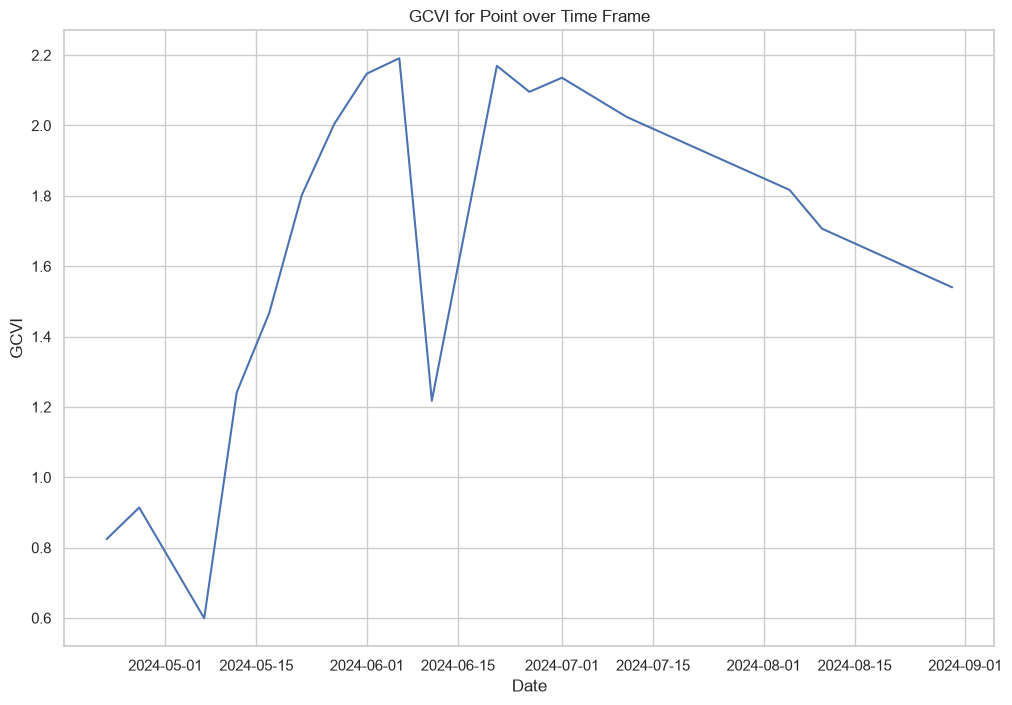

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
sns.set(style='whitegrid')

f,ax=plt.subplots(1,1, figsize=(12,8))

line = sns.lineplot(x='date',y='GCVI',data=gcvi_day_pixel_df,ax=ax)
ax.set_title('GCVI for Point over Time Frame')

ax.set_ylabel('GCVI')
ax.set_xlabel('Date')

In [30]:
import sys
# sys.path.append(r"C:\Users\John.local\Documents\Drive D\Test\eetc\eetc\gee_tools")
sys.path.append(str(Path.cwd() / "eetc" / "gee_tools"))
import harmonics

#### Obtaining/Fitting a Harmonic regression model to the Time Series of each band

In [31]:
# Import code we'll use from Azzari et al.
#from eetc.gee_tools import harmonics

# Filter for only our index of interest in this example, GCVI
gcvi = s2coll_2a.select('GCVI')
# Specify band in the ImageCollection we want to use in regression
dep_bands = ['GCVI']

# Run the regression to produce an image with our terms as bands; using first day of growing season as refdate
hrmregr_coefs_gcvi = harmonics.run_std_regressions(gcvi,dep_bands,refdate='2024-03-01')

In [32]:
# Cycle through the bands to see our result
for band in hrmregr_coefs_gcvi.getInfo()['bands']:
    print(band['id'])

GCVI_sin2
GCVI_cos2
GCVI_sin1
GCVI_cos1
GCVI_t
GCVI_constant
GCVI_variance
GCVI_count
GCVI_mean
GCVI_rmse
GCVI_r2


**These steps are optional**

In [33]:
# Filter for only our index of interest in this example, GCVI
gcvi_ext = s2coll_2a_ext.select('GCVI')
# Specify band in the ImageCollection we want to use in regression
dep_bands = ['GCVI']

# Run the regression to produce an image with our terms as bands; using first day of growing season as refdate (we are producing the coefficients) 
hrmregr_coefs_gcvi_ext = harmonics.run_std_regressions(gcvi_ext,dep_bands,refdate='2024-03-01')

In [34]:
# create new, smoothed GCVI values by fitting the original to the harmonic regression with coefficients created above
hrmregr_fit_gcvi_ext = harmonics.fit_harmonics(hrmregr_coefs_gcvi_ext, gcvi_ext, omega=1,nharmonics=2,bands=dep_bands,refdate='2024-03-01')

In [35]:
# generate lists of known images where our location is not masked
def create_lists_for_extract(df, suffix_to_remove, suffix_to_add):
    """
    Create list of band ids and timestamps from previously-generated
        DataFrame from extract_pixel_vals_dates(). 
    Inputs:
        df (DataFrame): DataFrame returned from extract_pixel_vals_dates()
        suffix_to_remove (str): original suffix added to Image system:index, 
            in the format of '_' + bandname
        suffix_to_add (str): new suffix to add to Image system:index in format
            '_' + new bandname
    Returns (list, list): list of timestamps, list of band ids as tuple
    """
    time_list = df['datetime'].to_list()
    band_list = df['band_id'].to_list()
    band_list = [band.replace(suffix_to_remove, '') for band in band_list]
    band_list = [band + suffix_to_add for band in band_list]

    return time_list, band_list

In [36]:
time_list, band_list = create_lists_for_extract(gcvi_time_pixel_vals, '_GCVI','_GCVI_HARMFIT')
band_list[0:5]

['20240422T073621_20240422T075353_T36MZE_GCVI_HARMFIT',
 '20240422T073621_20240422T075353_T37MBV_GCVI_HARMFIT',
 '20240427T073609_20240427T075435_T36MZE_GCVI_HARMFIT',
 '20240427T073609_20240427T075435_T37MBV_GCVI_HARMFIT',
 '20240507T073619_20240507T075437_T36MZE_GCVI_HARMFIT']

In [37]:
# use our function to extract values for each pixel
# NOTE: this will be VERY slow, much slower than the for the original values even using pre-filtered lists - choose a smaller time frame to minimize processing
# using Google Earth Engine to perform these calculations and extract as a .csv is also an option for faster processing
# gcvi_hrmregr_time_pixel_vals = extract_pixel_vals_dates(hrmregr_fit_gcvi_ext, 'GCVI_HARMFIT', ee_point_g,band_list=band_list, time_list=time_list)

In [38]:
# save as csv to avoid repeating the processing
# gcvi_hrmregr_time_pixel_vals.to_csv('nyandarua_gcvi_hrmregr_ext_time_pixel_vals_pointg4.csv',index=False)

In [39]:
# Convert the csv to pandas
gcvi_hrmregr_time_pixel_vals = pd.read_csv("nyandarua_gcvi_hrmregr_ext_time_pixel_vals_pointg4.csv")
gcvi_hrmregr_time_pixel_vals 

,datetime,GCVI_HARMFIT,band_id
0,2024-04-22 08:00:15,0.793048,20240422T073621_20240422T075353_T36MZE_GCVI_HA...
1,2024-04-22 08:00:13,0.848864,20240422T073621_20240422T075353_T37MBV_GCVI_HA...
2,2024-04-27 08:00:11,0.787723,20240427T073609_20240427T075435_T36MZE_GCVI_HA...
3,2024-04-27 08:00:09,0.726441,20240427T073609_20240427T075435_T37MBV_GCVI_HA...
4,2024-05-07 08:00:13,1.016121,20240507T073619_20240507T075437_T36MZE_GCVI_HA...
5,2024-05-07 08:00:11,0.922055,20240507T073619_20240507T075437_T37MBV_GCVI_HA...
6,2024-05-12 08:00:15,1.195534,20240512T073621_20240512T075440_T36MZE_GCVI_HA...
7,2024-05-12 08:00:13,1.144199,20240512T073621_20240512T075440_T37MBV_GCVI_HA...
8,2024-05-17 08:00:10,1.388014,20240517T073609_20240517T075434_T36MZE_GCVI_HA...
9,2024-05-17 08:00:08,1.395741,20240517T073609_20240517T075434_T37MBV_GCVI_HA...


In [40]:
# convert to datetime type
gcvi_hrmregr_time_pixel_vals['datetime'] = pd.to_datetime(gcvi_hrmregr_time_pixel_vals['datetime'])
gcvi_hrmregr_time_pixel_vals
# # # extract date from datetime
gcvi_hrmregr_time_pixel_vals['date'] = gcvi_hrmregr_time_pixel_vals['datetime'].dt.date
# group data by date, take mean of all GCVI_HARMFIT values for each date
gcvi_hrmregr_day_pixel_df = gcvi_hrmregr_time_pixel_vals.groupby('date')['GCVI_HARMFIT'].mean().reset_index()
gcvi_hrmregr_day_pixel_df.head()

,date,GCVI_HARMFIT
0,2024-04-22,0.820956
1,2024-04-27,0.757082
2,2024-05-07,0.969088
3,2024-05-12,1.169867
4,2024-05-17,1.391878


In [41]:
gcvi_hrmregr_day_pixel_df['date_ordinal'] = pd.to_datetime(gcvi_hrmregr_day_pixel_df['date']).apply(lambda date: date.toordinal())
gcvi_day_pixel_df['date_ordinal'] = pd.to_datetime(gcvi_day_pixel_df['date']).apply(lambda date: date.toordinal())

gcvi_hrmregr_day_pixel_df.head()

,date,GCVI_HARMFIT,date_ordinal
0,2024-04-22,0.820956,738998
1,2024-04-27,0.757082,739003
2,2024-05-07,0.969088,739013
3,2024-05-12,1.169867,739018
4,2024-05-17,1.391878,739023


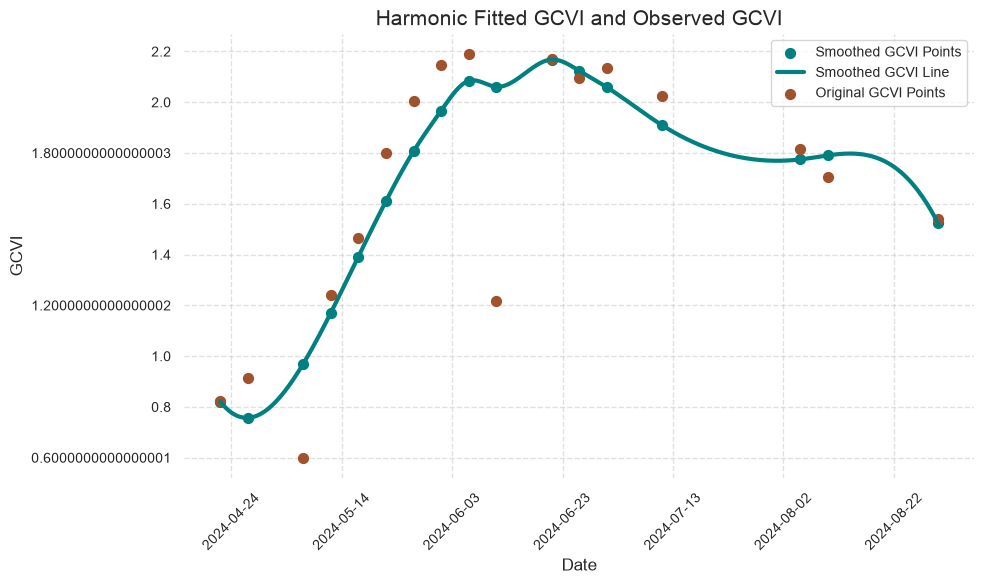

In [42]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from datetime import date

# Obtain the original dates and GCVI values for plot f to use as comparison to our smoothed values
x_orig = gcvi_day_pixel_df['date_ordinal']
y_orig = gcvi_day_pixel_df['GCVI']

# Obtain plot f dates and smoothed GCVI values to use as our x and y values
x = gcvi_hrmregr_day_pixel_df['date_ordinal']
y = gcvi_hrmregr_day_pixel_df['GCVI_HARMFIT']

# Ensure no NaN values in x and y
x = x[~np.isnan(y)]
y = y[~np.isnan(y)]

# Create 500 evenly spaced numbers over the range of our ordinal dates
xnew = np.linspace(x.min(), x.max(), 500)

# Approximate our function from the date and GCVI values
f = interp1d(x, y, kind='cubic')
# Create y values, using our approximated function, to pair with our 500 x values
y_smooth = f(xnew)

# Create a figure and axis
fig, ax = plt.subplots(figsize=(10, 6))

# Plot the smoothed GCVI points from our dataset
ax.scatter(x, y, c='teal', s=50, label='Smoothed GCVI Points')
# Plot the smoothed line connecting the points
ax.plot(xnew, y_smooth, c='teal', linewidth=3, label='Smoothed GCVI Line')
# Plot the original GCVI points from our dataset
ax.scatter(x_orig, y_orig, c='sienna', s=50, label='Original GCVI Points')

# Define the axes and title labels
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('GCVI', fontsize=12)
ax.set_title('Harmonic Fitted GCVI and Observed GCVI', fontsize=15)

# Create dates from ordinal dates to use along x-axis for easy interpretation
date_labels = [date.fromordinal(int(item)) for item in ax.get_xticks() if item >= 1]
ax.set_xticklabels(date_labels, rotation=45, fontsize=10)
ax.set_yticklabels(ax.get_yticks(), fontsize=10)

# Remove bounding box from plot
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)

# Add gridlines
ax.grid(True, linestyle='--', alpha=0.6)

# Add a legend
ax.legend(loc='upper right', fontsize=10)

# Show the plot
plt.tight_layout()
plt.savefig('gcvi_plot.png', dpi=300, bbox_inches='tight')  # Save the plot
plt.show()

In [43]:
# convert the Survey GeoDataFrame to an Earth Engine object for visualization and localization of our fields of interest
ee_plots_gdf = geemap.geopandas_to_ee(survey_gdf.loc[:,('fid','geometry')])
ee_plots_gdf.getInfo()

{'type': 'FeatureCollection',
 'columns': {'fid': 'Integer', 'system:index': 'String'},
 'features': [{'type': 'Feature',
   'geometry': {'type': 'Polygon',
    'coordinates': [[[36.26121067283256, -0.100925039676083],
      [36.261464007548234, -0.101070263398443],
      [36.26154630099091, -0.100960538808215],
      [36.26123164959246, -0.100786270341383],
      [36.260952497326144, -0.100674932154239],
      [36.26092345258167, -0.100768520775316],
      [36.26121067283256, -0.100925039676083]]]},
   'id': '0',
   'properties': {'fid': 26}},
  {'type': 'Feature',
   'geometry': {'type': 'Polygon',
    'coordinates': [[[36.29380089312641, -0.032767512779927],
      [36.293728281265224, -0.032922418083778],
      [36.29386059621227, -0.032922418083778],
      [36.29392191289504, -0.032778807958333],
      [36.29380089312641, -0.032767512779927]]]},
   'id': '1',
   'properties': {'fid': 27}},
  {'type': 'Feature',
   'geometry': {'type': 'Polygon',
    'coordinates': [[[36.29593326144

## Batch Processing of harmonic regression coefficients for feature engineering.

**Service account setup (recommended for automated exports)**\n
Run the commands below in a terminal to create a service account, grant it permissions, and create a Cloud Storage bucket for exports. Replace `PROJECT_ID` and `SA_NAME` accordingly.

In [44]:
# Example commands (run these in your shell, not in the notebook):
# Create service account:
# gcloud iam service-accounts create SA_NAME --display-name=ee-export-sa --project=PROJECT_ID
# Grant roles: (Storage for exports, Earth Engine access)
# gcloud projects add-iam-policy-binding PROJECT_ID --member="serviceAccount:SA_NAME@PROJECT_ID.iam.gserviceaccount.com" --role="roles/storage.admin"
# (Optional) Grant broader EE role if needed:
# gcloud projects add-iam-policy-binding PROJECT_ID --member="serviceAccount:SA_NAME@PROJECT_ID.iam.gserviceaccount.com" --role="roles/earthengine.admin"
# Create a Cloud Storage bucket for exports:
# gsutil mb -p PROJECT_ID -l us-central1 gs://PROJECT_ID-ee-exports
# Make sure the service account can write to the bucket (storage admin role covers this)

# After creating the key file, download it and save it as: path/to/service-account-key.json
# Then initialize Earth Engine in the notebook with the service account credentials as shown below.

In [45]:
# # Service-account based EE initialization (replace path and project)
# import ee
# from google.oauth2 import service_account

# SCOPES = [
#   'https://www.googleapis.com/auth/earthengine',
#   'https://www.googleapis.com/auth/devstorage.full_control',  # for Cloud Storage exports
#   'https://www.googleapis.com/auth/drive'  # optional; Drive exports usually require user credentials
# ]

# # Path to the JSON key you downloaded for the service account
# SERVICE_ACCOUNT_KEY = 'path/to/service-account-key.json'  # <- update this
# GCP_PROJECT = ' ee-xtinemuthee'  # <- update this

# credentials = service_account.Credentials.from_service_account_file(SERVICE_ACCOUNT_KEY, scopes=SCOPES)
# ee.Initialize(credentials=credentials, project=GCP_PROJECT, opt_url='https://earthengine-highvolume.googleapis.com')
# print('Initialized Earth Engine with service account — exports should go to Cloud Storage')

In [46]:
# BATCH_SIZE = 5  # Process x features at a time

# def process_and_export(batch, batch_number):
#     batch_gcvi = hrmregr_coefs_gcvi.reduceRegions(
#         reducer=ee.Reducer.mean(),
#         collection=batch,
#         scale=30
#     )
#     # Creates a batch task to export a FeatureCollection to Google Drive as a CSV file
#     task = ee.batch.Export.table.toDrive(
#         collection=batch_gcvi,
#         description=f'GCVI_Batch_2{batch_number}',
#         folder='GEE_Exports',
#         fileNamePrefix=f'gcvi_batch_{batch_number}',
#         fileFormat='CSV'
#     )
#     task.start()
#     print(f"✅ Export started for Batch {batch_number}")


# for i in range(0, 161, BATCH_SIZE):
#     batch = ee_plots_gdf.toList(BATCH_SIZE, i)
#     batch_fc = ee.FeatureCollection(batch)
#     process_and_export(batch_fc, i // BATCH_SIZE + 1)



In [47]:
# BATCH_SIZE = 8  # Adjust batch size based on memory limits

# def process_and_export(batch, batch_number, band):
#     """Runs harmonic regression and exports results in batches."""
#     imgcoll = s2coll_2a.select([band])  # Select current band
#     hrmregr_img = harmonics.run_std_regressions(imgcoll, [band], None)  # Harmonic regression

#     batch_results = hrmregr_img.reduceRegions(
#         reducer=ee.Reducer.mean(),
#         collection=batch,
#         scale=30
#     )
    
#     task = ee.batch.Export.table.toDrive(
#         collection=batch_results,
#         description=f'{band}_Batch_{batch_number}',
#         folder='GEE_Exports',
#         fileNamePrefix=f'{band.lower()}_batch_{batch_number}',
#         fileFormat='CSV'
#     )
#     task.start()
#     print(f"✅ Export started for {band} - Batch {batch_number}")

# for band in bands_indices:
#     size = ee_plots_gdf.size().getInfo()  # Get total feature count
#     for i in range(0, size, BATCH_SIZE):
#         batch = ee_plots_gdf.toList(BATCH_SIZE, i)
#         batch_fc = ee.FeatureCollection(batch)
#         process_and_export(batch_fc, i // BATCH_SIZE + 1, band)


In [48]:
# #import time ### THE CORRECT ONE
# # define bands of interest
# bands_indices = ['RDED4','GCVI','NBR1','NDTI','NDVI','SNDVI']
# BATCH_SIZE = 5  # Adjust batch size based on memory
# task_dict = {}  # Store task IDs and batch info

# def process_and_export(batch, batch_number, band):
#     #"""Runs harmonic regression and exports results in batches."""
#     imgcoll = s2coll_2a.select([band])  # Select current band
#     hrmregr_img = harmonics.run_std_regressions(imgcoll, [band], None)  # Harmonic regression
#     # Get the mean values for the batch of features
#     batch_results = hrmregr_img.reduceRegions(
#         reducer=ee.Reducer.mean(),
#         collection=batch,
#         scale=30
#     )
    
#     task = ee.batch.Export.table.toDrive(
#         collection=batch_results,
#         description=f'{band}_Batch_{batch_number}',
#         folder='GEE_Exports_All_Bands',
#         fileNamePrefix=f'{band.lower()}_batch_{batch_number}',
#         fileFormat='CSV'
#     )
#     task.start()
    
#     ## Store task information
#     task_dict[task.id] = {
#         "band": band,
#         "batch_number": batch_number,
#         "task": task
#     }
#     print(f"✅ Export started for {band} - Batch {batch_number} (Task ID: {task.id})")

# ## Start the batch export process
# for band in bands_indices:
#     size = ee_plots_gdf.size().getInfo()
#     for i in range(0, size, BATCH_SIZE):
#         batch = ee_plots_gdf.toList(BATCH_SIZE, i)
#         batch_fc = ee.FeatureCollection(batch)
#         process_and_export(batch_fc, i // BATCH_SIZE + 1, band)

In [49]:
# from pathlib import Path
# import pandas as pd

# def concat_band(folder: Path, band_prefix: str) -> pd.DataFrame:
#     files = sorted(folder.glob(f"{band_prefix}_batch_*.csv"))
#     if not files:
#         print(f"No files found for {band_prefix}")
#         return pd.DataFrame()
#     dfs = []
#     for f in files:
#         df = pd.read_csv(f)
#         # df["source_file"] = f.name
#         dfs.append(df)
#     return pd.concat(dfs, axis=0, ignore_index=True)

# # Update this to your export folder on the SSD or mounted Drive
# folder = Path("/Volumes/PortableSSD/GEE_Exports_All_Bands")

# # Example: concatenate GCVI batches
# # gcvi_df = concat_band(folder, "gcvi")
# # gcvi_df.to_csv(folder / "gcvi_concatenated.csv", index=False)
# # print("gcvi_concatenated:", gcvi_df.shape)

# # Concatenate other bands and merge side-by-side on 'fid'
# bands = ["gcvi", "nbr1", "ndvi", "rded4", "ndti", "sndvi"]
# band_dfs = {b: concat_band(folder, b) for b in bands}

# # Ensure 'fid' exists and merge
# for b, df in band_dfs.items():
#     if df.empty:
#         continue
#     if "fid" not in df.columns:
#         raise KeyError(f"'fid' column not found in {b} files")

# merged = None
# for b, df in band_dfs.items():
#     if df.empty:
#         continue
#     # drop duplicated columns except 'fid'
#     cols = [c for c in df.columns if c != "fid"]
#     df = df[["fid"] + cols]
#     if merged is None:
#         merged = df
#     else:
#         merged = merged.merge(df, on="fid", how="inner", suffixes=("", f"_{b}"))
# current_directory = Path.cwd()
# if merged is not None:
#     merged.to_csv( current_directory / "merged_all_bands_1.csv", index=False)
#     print("merged_all_bands:", merged.shape)
# else:
#     print("No data to merge.")

In [50]:
# Define file path
file_path = "merged_all_bands_1.csv"

# Read CSV into a DataFrame
s2_2a_df = pd.read_csv(file_path)
s2_2a_df.head(50)


,fid,system:index,GCVI_constant,GCVI_cos1,GCVI_cos2,GCVI_count,GCVI_mean,GCVI_r2,GCVI_rmse,GCVI_sin1,...,SNDVI_cos2,SNDVI_count,SNDVI_mean,SNDVI_r2,SNDVI_rmse,SNDVI_sin1,SNDVI_sin2,SNDVI_t,SNDVI_variance,.geo_sndvi
0,26,0,1.325704,-0.363224,-0.060715,38.159420,1.149106,0.393228,0.164901,-0.081504,...,-0.149469,38.159420,0.294761,0.660541,0.036694,-0.605819,-0.070230,-2.937199,0.002732,"{""type"":""Polygon"",""coordinates"":[[[36.26121067..."
1,27,1,-120.368161,6.452864,2.296430,48.015625,1.150957,0.527538,0.236755,56.164286,...,0.451693,48.015625,0.286838,0.576825,0.046460,11.852063,1.775246,53.052203,0.006034,"{""type"":""Polygon"",""coordinates"":[[[36.29380089..."
2,28,2,5.438043,0.619001,0.244187,67.459459,1.244034,0.662210,0.153033,-2.654621,...,-0.116135,67.459459,0.320933,0.795850,0.033720,-1.626339,-0.374590,-6.165445,0.006573,"{""type"":""Polygon"",""coordinates"":[[[36.29593326..."
3,29,3,49.080745,-1.368978,-0.054804,57.630522,1.355241,0.775576,0.178418,-22.762854,...,-0.069150,57.630522,0.338498,0.870087,0.030441,-3.725692,-0.603706,-15.862050,0.007304,"{""type"":""Polygon"",""coordinates"":[[[36.29796800..."
4,30,4,-8.949218,-2.580436,-0.718864,95.463733,1.317417,0.531558,0.180222,3.679194,...,-0.128326,95.463733,0.318162,0.684416,0.034587,-0.874210,-0.109817,-3.618079,0.004209,"{""type"":""Polygon"",""coordinates"":[[[36.30828373..."
5,31,5,1.755331,1.992924,0.909893,72.197753,1.148896,0.704324,0.094328,-0.042564,...,0.188668,72.197753,0.306939,0.950467,0.017661,-0.939566,-0.160511,-3.799515,0.002730,"{""type"":""Polygon"",""coordinates"":[[[36.34523832..."
6,32,6,0.769783,1.383108,0.617361,40.413564,1.252311,0.540728,0.188623,-0.148211,...,-0.000524,40.413564,0.312788,0.686421,0.032609,-1.144597,-0.220109,-4.385141,0.003622,"{""type"":""Polygon"",""coordinates"":[[[36.34545939..."
7,33,7,11.371949,-1.212245,-0.299239,118.764706,1.237270,0.678947,0.206415,-5.791746,...,-0.278449,118.764706,0.310793,0.788820,0.039093,-2.418796,-0.482765,-10.002819,0.007253,"{""type"":""Polygon"",""coordinates"":[[[36.31991050..."
8,34,8,18.440934,-2.582352,-1.220668,86.789092,1.833928,0.813166,0.234707,-9.021713,...,-0.112724,86.789092,0.411060,0.814287,0.039980,-0.909757,-0.328761,-3.368098,0.008670,"{""type"":""Polygon"",""coordinates"":[[[36.35579851..."
9,35,9,14.197277,-3.829325,-1.209243,66.075163,1.307809,0.621051,0.183703,-6.888013,...,-0.359784,66.075163,0.320294,0.730355,0.037460,-1.964244,-0.241588,-8.761845,0.004999,"{""type"":""Polygon"",""coordinates"":[[[36.36262402..."


In [51]:
# Display the columns of interest (exclude NDTI_r2 because it was empty all through)
clean_df = s2_2a_df[['GCVI_constant', 'GCVI_cos1', 'GCVI_cos2', 'GCVI_count', 'GCVI_mean',
    'GCVI_r2', 'GCVI_rmse', 'GCVI_sin1', 'GCVI_sin2', 'GCVI_t',
    'GCVI_variance', 'NBR1_constant', 'NBR1_cos1', 'NBR1_cos2',
    'NBR1_count', 'NBR1_mean', 'NBR1_r2', 'NBR1_rmse', 'NBR1_sin1',
    'NBR1_sin2', 'NBR1_t', 'NBR1_variance', 'NDTI_constant', 'NDTI_cos1',
    'NDTI_cos2', 'NDTI_count', 'NDTI_mean', 'NDTI_rmse',
    'NDTI_sin1', 'NDTI_sin2', 'NDTI_t', 'NDTI_variance', 'NDVI_constant',
    'NDVI_cos1', 'NDVI_cos2', 'NDVI_count', 'NDVI_mean', 'NDVI_r2',
    'NDVI_rmse', 'NDVI_sin1', 'NDVI_sin2', 'NDVI_t', 'NDVI_variance',
    'RDED4_constant', 'RDED4_cos1', 'RDED4_cos2', 'RDED4_count',
    'RDED4_mean', 'RDED4_r2', 'RDED4_rmse', 'RDED4_sin1', 'RDED4_sin2',
    'RDED4_t', 'RDED4_variance', 'SNDVI_constant', 'SNDVI_cos1',
    'SNDVI_cos2', 'SNDVI_count', 'SNDVI_mean', 'SNDVI_r2', 'SNDVI_rmse',
    'SNDVI_sin1', 'SNDVI_sin2', 'SNDVI_t', 'SNDVI_variance', 'fid','.geo']]
clean_df.shape

(131, 67)

In [52]:
clean_df.head(70)

,GCVI_constant,GCVI_cos1,GCVI_cos2,GCVI_count,GCVI_mean,GCVI_r2,GCVI_rmse,GCVI_sin1,GCVI_sin2,GCVI_t,...,SNDVI_count,SNDVI_mean,SNDVI_r2,SNDVI_rmse,SNDVI_sin1,SNDVI_sin2,SNDVI_t,SNDVI_variance,fid,.geo
0,1.325704,-0.363224,-0.060715,38.159420,1.149106,0.393228,0.164901,-0.081504,0.006413,-0.793377,...,38.159420,0.294761,0.660541,0.036694,-0.605819,-0.070230,-2.937199,0.002732,26,"{""type"":""Polygon"",""coordinates"":[[[36.26121067..."
1,-120.368161,6.452864,2.296430,48.015625,1.150957,0.527538,0.236755,56.164286,8.277519,251.956365,...,48.015625,0.286838,0.576825,0.046460,11.852063,1.775246,53.052203,0.006034,27,"{""type"":""Polygon"",""coordinates"":[[[36.29380089..."
2,5.438043,0.619001,0.244187,67.459459,1.244034,0.662210,0.153033,-2.654621,-0.959450,-7.343085,...,67.459459,0.320933,0.795850,0.033720,-1.626339,-0.374590,-6.165445,0.006573,28,"{""type"":""Polygon"",""coordinates"":[[[36.29593326..."
3,49.080745,-1.368978,-0.054804,57.630522,1.355241,0.775576,0.178418,-22.762854,-3.735865,-97.401218,...,57.630522,0.338498,0.870087,0.030441,-3.725692,-0.603706,-15.862050,0.007304,29,"{""type"":""Polygon"",""coordinates"":[[[36.29796800..."
4,-8.949218,-2.580436,-0.718864,95.463733,1.317417,0.531558,0.180222,3.679194,0.682081,16.999245,...,95.463733,0.318162,0.684416,0.034587,-0.874210,-0.109817,-3.618079,0.004209,30,"{""type"":""Polygon"",""coordinates"":[[[36.30828373..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65,50.070348,-8.011109,-2.425467,48.291845,1.287344,0.658451,0.173459,-25.978242,-4.419072,-108.665657,...,48.291845,0.324622,0.677030,0.037871,-3.105903,-0.566749,-12.420346,0.004644,40,"{""type"":""Polygon"",""coordinates"":[[[36.37002075..."
66,-12.442473,-2.051774,-0.746264,46.239286,1.301178,0.808617,0.087675,5.108994,0.435455,24.619913,...,46.239286,0.352942,0.912443,0.016410,5.173167,0.709494,23.421674,0.002059,41,"{""type"":""Polygon"",""coordinates"":[[[36.36562370..."
67,71.538978,1.235394,0.310990,45.923843,1.121781,0.717585,0.088568,-32.088464,-5.276140,-139.082155,...,45.923843,0.284671,0.822589,0.020090,-10.045867,-1.618861,-43.717107,0.001953,42,"{""type"":""Polygon"",""coordinates"":[[[36.39015683..."
68,27.129609,-2.837267,-0.738460,63.043362,1.304464,0.731450,0.121531,-12.964420,-2.009946,-55.558992,...,63.043362,0.328494,0.795468,0.025357,-2.155229,-0.328160,-9.176819,0.003632,43,"{""type"":""Polygon"",""coordinates"":[[[36.40835820..."


### Topographical Features

In [53]:
# define GEE id of SRTM V3 Image
srtm = ee.Image('USGS/SRTMGL1_003')

In [54]:
elevation = srtm.select('elevation')
slope = ee.Terrain.slope(elevation)
aspect = ee.Terrain.aspect(elevation)

In [55]:
# Calculate mean slope for area
slope_c = slope.reduceRegion(
    reducer = ee.Reducer.mean(),
    geometry = ee_point_g,
    scale = 30
)
mean_slope_c = slope_c.get('slope')
print('Mean slope for plot c:',mean_slope_c.getInfo())


Mean slope for plot c: 4.718663628023238


In [56]:
# this is not a real plot from any survey data; it was randomly selected for demonstration
center_lat = -0.309634
center_lon = 36.381935


elev_map = geemap.Map(center=[center_lat,center_lon], zoom=9)
elev_map.addLayer(slope, {min:0, max: 90}, 'slope')
elev_map

Map(center=[-0.309634, 36.381935], controls=(WidgetControl(options=['position', 'transparent_bg'], position='t…

In [57]:
# this is not a real plot from any survey data; it was randomly selected for demonstration
center_lat = -0.309634
center_lon = 36.381935


map_plot_c = geemap.Map(center=[center_lat,center_lon],zoom=6)

terrain_params = {'min': 0, 'max': 1000, 'palette': [
    '3ae237', 'b5e22e', 'd6e21f', 'fff705', 'ffd611', 'ffb613', 'ff8b13',
    'ff6e08', 'ff500d', 'ff0000', 'de0101', 'c21301', '0602ff', '235cb1',
    '307ef3', '269db1', '30c8e2', '32d3ef', '3be285', '3ff38f', '86e26f'
  ]}
map_plot_c.addLayer(elevation, terrain_params, 'elevation')
map_plot_c

Map(center=[-0.309634, 36.381935], controls=(WidgetControl(options=['position', 'transparent_bg'], position='t…

#### Obtain mean elevation, slope and aspect for every plot

In [58]:
import pandas as pd

# Define measures of interest
measure_images = {'elevation': elevation, 'slope': slope, 'aspect': aspect}

# Create an empty DataFrame to store results
srtm_df = pd.DataFrame()

# For each measure, calculate the mean for all plots
for label, img in measure_images.items():
    # Calculate mean using reduceRegions
    means = img.reduceRegions(
        reducer=ee.Reducer.mean(),
        collection=ee_plots_gdf,
        scale=30
    )

    # Extract features and convert to a Pandas DataFrame
    features = means.getInfo()['features']
    data = []
    for feature in features:
        props = feature['properties']
        data.append({'fid': props['fid'], label: props['mean']})
    means_df = pd.DataFrame(data)

    # Merge DataFrame with the main DataFrame
    if srtm_df.empty:
        srtm_df = means_df.copy()
    else:
        srtm_df = srtm_df.merge(means_df, on='fid')

# Display the resulting DataFrame
srtm_df


,fid,elevation,slope,aspect
0,26,2683.151625,6.361734,288.871736
1,27,2514.000000,7.789299,159.516666
2,28,2497.647059,5.998055,81.743388
3,29,2481.000000,9.063557,120.810240
4,30,2444.404446,4.676826,295.564851
...,...,...,...,...
156,182,2408.666538,3.880746,151.931177
157,183,2408.907246,3.037420,198.582127
158,184,2359.033094,3.108565,169.031151
159,185,2349.697266,5.312524,37.307613


### Sample precipitation for every plot. 

In [59]:
# this is not a real plot from any survey data; it was randomly selected for demonstration
center_lat = -0.309634
center_lon = 36.381935

precip_point_g = geemap.Map(center=[center_lat,center_lon],zoom=7)
precip_point_g.add_basemap('SATELLITE')

# select precipitation for the range of dates in the growing season
precip = ee.ImageCollection('UCSB-CHG/CHIRPS/DAILY').\
    filter(ee.Filter.date('2018-11-20', '2019-04-20')).select('precipitation')

precip_params = {'min': 1.0, 'max': 17.0,\
  'palette': ['001137', '0aab1e', 'e7eb05', 'ff4a2d', 'e90000'],}
precip_point_g.addLayer(precip, precip_params, 'Precipitation');
precip_point_g

Map(center=[-0.309634, 36.381935], controls=(WidgetControl(options=['position', 'transparent_bg'], position='t…

In [60]:
## Precipitation for every plot in the survey data
import pandas as pd

# Sum of all days in the precipitation ImageCollection
tot_precip = precip.reduce(ee.Reducer.sum()).reduceRegions(
    reducer=ee.Reducer.mean(),
    collection=ee_plots_gdf,
    scale=30
)

# Extract features and convert to a Pandas DataFrame
features = tot_precip.getInfo()['features']
weather_data = []
for feature in features:
    props = feature['properties']
    weather_data.append({'fid': props['fid'], 'precipitation': props['mean']})

# Create the DataFrame
weather_df = pd.DataFrame(weather_data)

# Display the DataFrame
weather_df

,fid,precipitation
0,26,159.938681
1,27,166.881517
2,28,166.881517
3,29,166.881517
4,30,179.458434
...,...,...
156,182,158.523374
157,183,158.523374
158,184,140.004858
159,185,160.810019


In [61]:
# since all other tables have unique_id as a float dtype, convert survey_gdf's fid to float to match
survey_gdf['fid'] = survey_gdf['fid'].astype('float64')
merged = survey_gdf.merge(weather_df, on='fid')
merged = merged.merge(clean_df, on='fid')
merged = merged.merge(srtm_df, on='fid')
merged.head()
# merged = pd.concat([survey_gdf, weather_df, clean_df, srtm_df], axis=1)
# merged

,fid,Farming_type,crop_a,crop_b,crop_c,crop_d,crop_e,sub-county,county,date_of_collection,...,SNDVI_r2,SNDVI_rmse,SNDVI_sin1,SNDVI_sin2,SNDVI_t,SNDVI_variance,.geo,elevation,slope,aspect
0,26.0,mono_cultu,Maize,NaN,None,None,None,Ol Jorok,Nyandarua,2024-07-12,...,0.660541,0.036694,-0.605819,-0.070230,-2.937199,0.002732,"{""type"":""Polygon"",""coordinates"":[[[36.26121067...",2683.151625,6.361734,288.871736
1,27.0,mono_cultu,Maize,NaN,None,None,None,Ol Jorok,Nyandarua,2024-07-12,...,0.576825,0.046460,11.852063,1.775246,53.052203,0.006034,"{""type"":""Polygon"",""coordinates"":[[[36.29380089...",2514.000000,7.789299,159.516666
2,28.0,mono_cultu,Maize,NaN,None,None,None,Ol Jorok,Nyandarua,2024-07-12,...,0.795850,0.033720,-1.626339,-0.374590,-6.165445,0.006573,"{""type"":""Polygon"",""coordinates"":[[[36.29593326...",2497.647059,5.998055,81.743388
3,29.0,mono_cultu,Maize,NaN,None,None,None,Ol Jorok,Nyandarua,2024-07-12,...,0.870087,0.030441,-3.725692,-0.603706,-15.862050,0.007304,"{""type"":""Polygon"",""coordinates"":[[[36.29796800...",2481.000000,9.063557,120.810240
4,30.0,mono_cultu,Maize,NaN,None,None,None,Ol Jorok,Nyandarua,2024-07-12,...,0.684416,0.034587,-0.874210,-0.109817,-3.618079,0.004209,"{""type"":""Polygon"",""coordinates"":[[[36.30828373...",2444.404446,4.676826,295.564851


In [62]:
merged.columns

Index(['fid', 'Farming_type', 'crop_a', 'crop_b', 'crop_c', 'crop_d', 'crop_e',
       'sub-county', 'county', 'date_of_collection', 'crop_growth_stage',
       'geometry', 'maize_pos', 'plot_area_acres', 'precipitation',
       'GCVI_constant', 'GCVI_cos1', 'GCVI_cos2', 'GCVI_count', 'GCVI_mean',
       'GCVI_r2', 'GCVI_rmse', 'GCVI_sin1', 'GCVI_sin2', 'GCVI_t',
       'GCVI_variance', 'NBR1_constant', 'NBR1_cos1', 'NBR1_cos2',
       'NBR1_count', 'NBR1_mean', 'NBR1_r2', 'NBR1_rmse', 'NBR1_sin1',
       'NBR1_sin2', 'NBR1_t', 'NBR1_variance', 'NDTI_constant', 'NDTI_cos1',
       'NDTI_cos2', 'NDTI_count', 'NDTI_mean', 'NDTI_rmse', 'NDTI_sin1',
       'NDTI_sin2', 'NDTI_t', 'NDTI_variance', 'NDVI_constant', 'NDVI_cos1',
       'NDVI_cos2', 'NDVI_count', 'NDVI_mean', 'NDVI_r2', 'NDVI_rmse',
       'NDVI_sin1', 'NDVI_sin2', 'NDVI_t', 'NDVI_variance', 'RDED4_constant',
       'RDED4_cos1', 'RDED4_cos2', 'RDED4_count', 'RDED4_mean', 'RDED4_r2',
       'RDED4_rmse', 'RDED4_sin1', 'RDED4_si

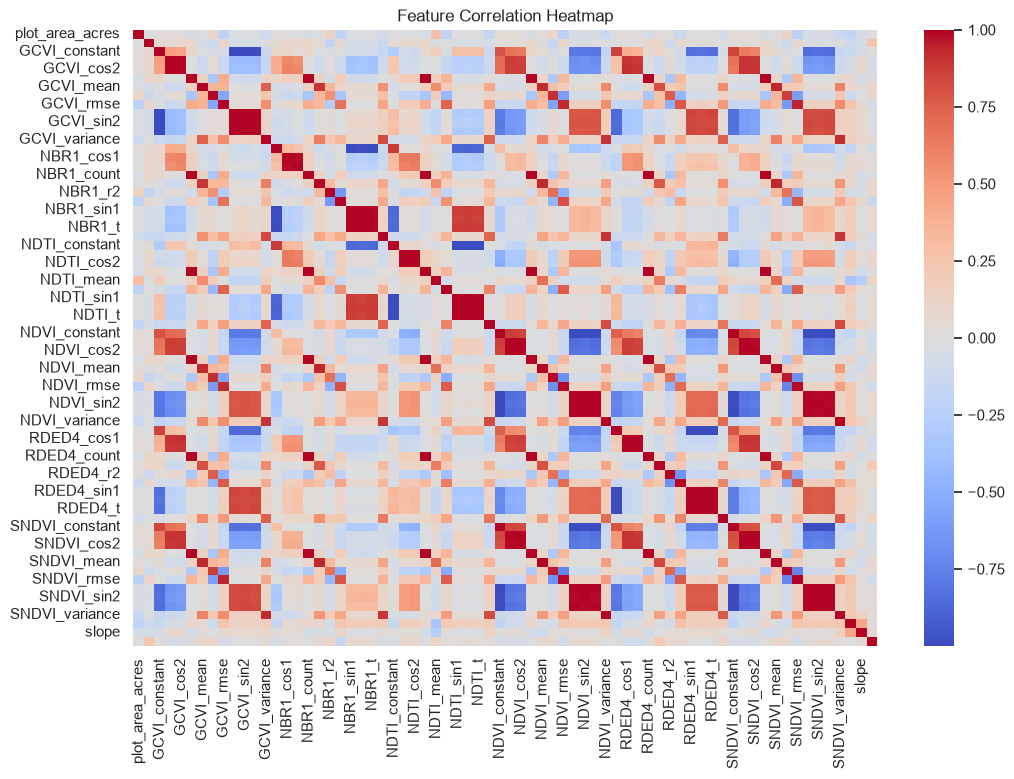

In [63]:
df = merged.drop(columns=['fid', 'date_of_collection','sub-county', 'county' , 'crop_growth_stage', 'maize_pos','geometry'])


# Drop non-numeric columns
numerical_df = df.select_dtypes(include=['number'])

# Compute correlation matrix
correlation_matrix = numerical_df.corr()

# Plot correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, cmap="coolwarm", annot=False)
plt.title("Feature Correlation Heatmap")
plt.show()


In [64]:
import numpy as np

# Compute absolute correlation matrix
correlation_matrix = numerical_df.corr().abs()

# Select upper triangle of correlation matrix to avoid duplicate values
upper_triangle = correlation_matrix.where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))

# Find features with high correlation (e.g., > 0.85)
high_corr_features = [column for column in upper_triangle.columns if any(upper_triangle[column] > 0.85)]

# Drop highly correlated features
df_reduced = numerical_df.drop(columns=high_corr_features)

print(f"Features removed due to high correlation: {high_corr_features}")
print(f"Remaining features: {df_reduced.columns.tolist()}")


Features removed due to high correlation: ['GCVI_cos2', 'GCVI_sin1', 'GCVI_sin2', 'GCVI_t', 'NBR1_cos2', 'NBR1_count', 'NBR1_mean', 'NBR1_sin1', 'NBR1_sin2', 'NBR1_t', 'NDTI_constant', 'NDTI_cos2', 'NDTI_count', 'NDTI_sin1', 'NDTI_sin2', 'NDTI_t', 'NDVI_cos1', 'NDVI_cos2', 'NDVI_count', 'NDVI_mean', 'NDVI_r2', 'NDVI_rmse', 'NDVI_sin1', 'NDVI_sin2', 'NDVI_t', 'NDVI_variance', 'RDED4_constant', 'RDED4_cos1', 'RDED4_cos2', 'RDED4_count', 'RDED4_sin1', 'RDED4_sin2', 'RDED4_t', 'SNDVI_constant', 'SNDVI_cos1', 'SNDVI_cos2', 'SNDVI_count', 'SNDVI_mean', 'SNDVI_r2', 'SNDVI_rmse', 'SNDVI_sin1', 'SNDVI_sin2', 'SNDVI_t', 'SNDVI_variance']
Remaining features: ['plot_area_acres', 'precipitation', 'GCVI_constant', 'GCVI_cos1', 'GCVI_count', 'GCVI_mean', 'GCVI_r2', 'GCVI_rmse', 'GCVI_variance', 'NBR1_constant', 'NBR1_cos1', 'NBR1_r2', 'NBR1_rmse', 'NBR1_variance', 'NDTI_cos1', 'NDTI_mean', 'NDTI_rmse', 'NDTI_variance', 'NDVI_constant', 'RDED4_mean', 'RDED4_r2', 'RDED4_rmse', 'RDED4_variance', 'elevat

In [65]:
# X= ['plot_area_acres', 'precipitation', 'GCVI_constant', 'GCVI_cos1', 'GCVI_count', 'GCVI_mean', 'GCVI_r2', 'GCVI_rmse', 'GCVI_variance', 'NBR1_constant', 'NBR1_cos1', 'NBR1_r2', 'NBR1_rmse', 'NBR1_variance', 'NDTI_cos1', 'NDTI_mean', 'NDTI_rmse', 'NDTI_variance', 'NDVI_constant', 'RDED4_mean', 'RDED4_r2', 'RDED4_rmse', 'RDED4_variance', 'elevation', 'slope', 'aspect']

In [66]:
merged['plot_area_acres']

0      0.243271
1      0.058804
2      0.097300
3      0.217708
4      3.602666
         ...   
126    2.255410
127    0.300339
128    1.579083
129    0.445634
130    1.745594
Name: plot_area_acres, Length: 131, dtype: float64

In [67]:
y = merged['maize_pos']
X = merged[[ 'precipitation', 'GCVI_constant', 'GCVI_cos1', 'GCVI_count', 'GCVI_mean', 
            'GCVI_r2', 'GCVI_rmse', 'GCVI_variance', 'NBR1_constant', 'NBR1_cos1', 
            'NBR1_r2', 'NBR1_rmse', 'NBR1_variance', 'NDTI_cos1', 'NDTI_mean', 
            'NDTI_rmse', 'NDTI_variance', 'NDVI_constant', 'RDED4_constant', 
            'RDED4_mean', 'RDED4_r2', 'RDED4_rmse', 'RDED4_variance', 
            'elevation', 'slope', 'aspect']]


In [68]:
X

,precipitation,GCVI_constant,GCVI_cos1,GCVI_count,GCVI_mean,GCVI_r2,GCVI_rmse,GCVI_variance,NBR1_constant,NBR1_cos1,...,NDTI_variance,NDVI_constant,RDED4_constant,RDED4_mean,RDED4_r2,RDED4_rmse,RDED4_variance,elevation,slope,aspect
0,159.938681,1.325704,-0.363224,38.159420,1.149106,0.393228,0.164901,0.040828,2.846125,-0.926343,...,0.000580,1.918465,0.929641,0.419211,0.497242,0.032869,0.001551,2683.151625,6.361734,288.871736
1,166.881517,-120.368161,6.452864,48.015625,1.150957,0.527538,0.236755,0.125716,-20.963585,1.452149,...,0.000920,-29.679028,-25.787239,0.380938,0.462544,0.054343,0.004690,2514.000000,7.789299,159.516666
2,166.881517,5.438043,0.619001,67.459459,1.244034,0.662210,0.153033,0.083932,5.112660,-0.983204,...,0.001112,3.840384,2.792694,0.420255,0.635767,0.033866,0.003020,2497.647059,5.998055,81.743388
3,166.881517,49.080745,-1.368978,57.630522,1.355241,0.775576,0.178418,0.140569,5.183804,-0.733387,...,0.000696,10.282804,0.810095,0.428600,0.652214,0.041472,0.005005,2481.000000,9.063557,120.810240
4,179.458434,-8.949218,-2.580436,95.463733,1.317417,0.531558,0.180222,0.078856,8.653778,-0.692541,...,0.000363,1.365512,5.523742,0.407952,0.413081,0.044653,0.003651,2444.404446,4.676826,295.564851
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
126,158.523374,-5.187987,-1.702667,33.333591,1.231771,0.744388,0.108283,0.041818,1.150636,-0.996631,...,0.000432,-0.556889,13.057789,0.428978,0.585165,0.037844,0.003347,2408.666538,3.880746,151.931177
127,158.523374,-182.928354,-17.120052,28.244898,1.306228,0.833170,0.115253,0.078810,-18.729769,-4.054484,...,0.000471,-43.434285,32.765482,0.439842,0.778163,0.029497,0.003379,2408.907246,3.037420,198.582127
128,140.004858,-4.957793,-3.025756,37.019391,1.531877,0.732679,0.155401,0.089401,-3.898820,-1.223910,...,0.000582,-2.777701,-1.927686,0.481202,0.711629,0.030234,0.003219,2359.033094,3.108565,169.031151
129,160.810019,90.233163,-4.026646,33.535156,1.481332,0.696284,0.156935,0.071885,-2.489061,-1.529688,...,0.000262,21.188875,25.284851,0.474283,0.679376,0.029122,0.002495,2349.697266,5.312524,37.307613


In [69]:
y

0      1
1      1
2      1
3      1
4      1
      ..
126    1
127    1
128    1
129    1
130    1
Name: maize_pos, Length: 131, dtype: int64

In [70]:
merged_selected = merged

# Machine Learning Section
- Feature Selection


In [71]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=100, stratify=merged[['maize_pos']]
)

- Training with Random Forest

In [72]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
rf_pipeline = Pipeline([
    ('rf', RandomForestClassifier())
    ])
rf_params = {
          'rf__n_estimators': (100,1000,5000),
          'rf__criterion': ('gini','entropy'),
          'rf__max_depth': (1,3,5),
          'rf__min_samples_split': (2,5,10),
          'rf__random_state': [10]
         }
k = 10

rf_grid_model = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_params,
    cv=k,
    scoring=['accuracy','precision','recall'],
    refit='accuracy' 
)

crop_fitted = rf_grid_model.fit(X_train, y_train)
crop_results = crop_fitted.cv_results_
crop_results = pd.DataFrame(crop_results)

In [73]:
crop_results.head(10)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_rf__criterion,param_rf__max_depth,param_rf__min_samples_split,param_rf__n_estimators,param_rf__random_state,params,...,split3_test_recall,split4_test_recall,split5_test_recall,split6_test_recall,split7_test_recall,split8_test_recall,split9_test_recall,mean_test_recall,std_test_recall,rank_test_recall
0,0.081143,0.002509,0.011266,0.001582,gini,1,2,100,10,"{'rf__criterion': 'gini', 'rf__max_depth': 1, ...",...,1.0,1.000000,1.0,1.0,1.0,1.0,1.0,1.000000,0.000000,1
1,0.847246,0.077456,0.078245,0.033172,gini,1,2,1000,10,"{'rf__criterion': 'gini', 'rf__max_depth': 1, ...",...,1.0,1.000000,1.0,1.0,1.0,1.0,1.0,1.000000,0.000000,1
2,5.380663,1.790436,0.364322,0.157331,gini,1,2,5000,10,"{'rf__criterion': 'gini', 'rf__max_depth': 1, ...",...,1.0,1.000000,1.0,1.0,1.0,1.0,1.0,1.000000,0.000000,1
3,0.086868,0.007539,0.011359,0.000757,gini,1,5,100,10,"{'rf__criterion': 'gini', 'rf__max_depth': 1, ...",...,1.0,1.000000,1.0,1.0,1.0,1.0,1.0,1.000000,0.000000,1
4,0.795982,0.040079,0.063117,0.001782,gini,1,5,1000,10,"{'rf__criterion': 'gini', 'rf__max_depth': 1, ...",...,1.0,1.000000,1.0,1.0,1.0,1.0,1.0,1.000000,0.000000,1
5,4.964682,1.442969,0.405702,0.215010,gini,1,5,5000,10,"{'rf__criterion': 'gini', 'rf__max_depth': 1, ...",...,1.0,1.000000,1.0,1.0,1.0,1.0,1.0,1.000000,0.000000,1
6,0.077992,0.000863,0.010685,0.001110,gini,1,10,100,10,"{'rf__criterion': 'gini', 'rf__max_depth': 1, ...",...,1.0,1.000000,1.0,1.0,1.0,1.0,1.0,1.000000,0.000000,1
7,0.826095,0.058633,0.063851,0.001208,gini,1,10,1000,10,"{'rf__criterion': 'gini', 'rf__max_depth': 1, ...",...,1.0,1.000000,1.0,1.0,1.0,1.0,1.0,1.000000,0.000000,1
8,3.938877,0.186709,0.291130,0.003435,gini,1,10,5000,10,"{'rf__criterion': 'gini', 'rf__max_depth': 1, ...",...,1.0,1.000000,1.0,1.0,1.0,1.0,1.0,1.000000,0.000000,1
9,0.084614,0.004710,0.010982,0.000687,gini,3,2,100,10,"{'rf__criterion': 'gini', 'rf__max_depth': 3, ...",...,1.0,0.888889,1.0,1.0,1.0,1.0,1.0,0.988889,0.033333,26


In [74]:
rf_grid_model.best_params_

{'rf__criterion': 'gini',
 'rf__max_depth': 5,
 'rf__min_samples_split': 2,
 'rf__n_estimators': 5000,
 'rf__random_state': 10}

In [75]:
rf_best = RandomForestClassifier(criterion = 'gini', max_depth = 3, min_samples_split = 2, n_estimators = 5000, random_state=10)
rf_best_fit = rf_best.fit(X_train, y_train)

In [76]:
# Save the best model to a file using joblib
import joblib
joblib.dump(rf_best_fit, 'rf_best_model.pkl')

['rf_best_model.pkl']

In [77]:
# Check the performance of the model with test set
y_pred = rf_best_fit.predict(X_test)
# Analysis make_scorer, accuracy_score, precision_score, recall_score
accuracy_score = accuracy_score(y_test,y_pred)
print("Accuracy:", accuracy_score)

Accuracy: 0.8518518518518519


### Apply the trained Model to a Full Area of Interest

In [97]:
# Lets try to obtain our entire Area of interest as pixel level 
import ee
import geemap
import gee_tools.datasources.sentinel2_2a as s2_2a
from eetc.gee_tools import harmonics

# Lets initialize our Earth Engine session
ee.Initialize()

#Define AOI for the entire Nyandarua County
aoi = ee.Geometry.Rectangle([36.2, -0.9, 36.9, -0.1])
# Define the center of the map (latitude, longitude)
center_lat = -0.289  
center_lon = 36.439  

map_nyandarua = geemap.Map(center=[center_lat,center_lon],zoom=6)

map_nyandarua.add_basemap("SATELLITE")
map_nyandarua.addLayer(aoi,vis_params={'color':'a4c639'},opacity=0.3)
map_nyandarua

Map(center=[-0.289, 36.439], controls=(WidgetControl(options=['position', 'transparent_bg'], position='toprigh…

In [ ]:
# Define Seasons
start_date = "2024-03-01"
end_date = "2024-09-30"
# same reference date of the start of the growing season.
reference_date = start_date

# Load Sentinel-2 L2A using eetc
s2coll_new = s2_2a.Sentinel2SR(
    aoi,
    start_date = start_date,
    end_date = end_date,
    addVIs = True,
    addCloudMasks=False
).get_img_coll() #This returns the S2 image collections  
print("Type:", type(s2coll_new))
print("Number of S2 images:", s2coll_new.size().getInfo())
print("Available bands:", s2coll_new.first().bandNames().getInfo())

# Understand if I need to perform cloud masking if SCL is there I can of not, just ignore
# Use Azzari et al's function to mask clouds
def maskClouds_sr(img, bandnames):
    scl = img.select(['SCL'])
    clear = scl.updateMask(scl.eq(4) Or (scl.eq(5)))
    img = img.updateMask(clear)
    return img.select(bandnames)
band_names = s2coll_new.first().bandNames().getInfo()

# Mask clouds using the function above
s2coll_2a = s2coll_new.map(lambda img: maskClouds_sr(img,band_names))
# Get new band names
for band in s2coll_2a.first().getInfo()['bands']:
    print(band['id'])


In [ ]:
# Select a subset of the bands Same s2 bands/indices used in training 
bands_indices = ["RDED4", "GCVI", "NBR1", "NDTI", "NDVI", "SNDVI"]
s2coll_2a = s2coll_2a.select(bands_indices)

# Now lets run harmonic regression
coef_images = []

for band in bands_indices:
    coef_img = harmonics.run_std_regressions(
        s2coll_2a.select([band]),
        [band],
        refdate=reference_date,
        nharmonics=2
    )
    coef_images.append(coef_img)

s2_feature_img = ee.Image.cat(coef_images)

print("Type of feature image:", type(s2_feature_img))
print("S2 feature bands:", s2_feature_img.bandNames().getInfo())


In [81]:
X.columns

Index(['precipitation', 'GCVI_constant', 'GCVI_cos1', 'GCVI_count',
       'GCVI_mean', 'GCVI_r2', 'GCVI_rmse', 'GCVI_variance', 'NBR1_constant',
       'NBR1_cos1', 'NBR1_r2', 'NBR1_rmse', 'NBR1_variance', 'NDTI_cos1',
       'NDTI_mean', 'NDTI_rmse', 'NDTI_variance', 'NDVI_constant',
       'RDED4_constant', 'RDED4_mean', 'RDED4_r2', 'RDED4_rmse',
       'RDED4_variance', 'elevation', 'slope', 'aspect'],
      dtype='str')

In [ ]:
# Lets add terrain features
srtm = ee.Image("USGS/SRTMGL1_003")
terrain = ee.Terrain.products(srtm)

terrain_features = terrain.select([
    "elevation",
    "slope",
    "aspect"
])

print(" Terrain Features:", terrain_features.bandNames().getInfo())
print(" Feature type", type(terrain_features))

# Add precipitation 
chirps = (
    ee.ImageCollection("UCSB-CHG/CHIRPS/DAILY")
    .filterDate(start_date,end_date)
    .filterBounds(aoi)
    .select("precipitation")
)
# Get the mean precipitation of that area
precip = chirps.mean().rename("precipitation")

print(" Precipitation:", precip.bandNames().getInfo())
print(" Feature type", type(precip))

# Build Full Feature Image
feature_img = (
    s2_feature_img
    .addBands(terrain_features)
    .addBands(precip)
    .clip(aoi)
)
print(" Image Feature type", type(feature_img))
print(" Image Feature bands:", feature_img.bandNames().getInfo())


In [ ]:
# We are only interested in the bands that match training band
feature_columns = [
    "precipitation",
    "GCVI_constant", "GCVI_cos1", "GCVI_count", "GCVI_mean",
    "GCVI_r2", "GCVI_rmse", "GCVI_variance",
    "NBR1_constant", "NBR1_cos1", "NBR1_r2", "NBR1_rmse", "NBR1_variance",
    "NDTI_cos1", "NDTI_mean", "NDTI_rmse", "NDTI_variance",
    "NDVI_constant",
    "RDED4_constant", "RDED4_mean", "RDED4_r2", "RDED4_rmse", "RDED4_variance",
    "elevation", "slope", "aspect"
]
feature_img = feature_img.select(feature_columns)
print("Final export bands:", feature_img.bandNames().getInfo())

In [ ]:
task = ee.batch.Export.image.toDrive(
    image=feature_img.toFloat(),
    description="nyandarua_pixel_features_for_rf",
    folder="crop_mapping",
    fileNamePrefix="nyandarua_pixel_features_for_rf",
    region=aoi,
    scale=30,
    maxPixels=1e13,
    fileFormat="GeoTIFF"
)

task.start()
print("Task ID:", task.id)
print("Task status:", task.status())

In [ ]:
# # Fetch model from pkl
# import pickle

# rf_best_model_path = "rf_best_model.pkl"
# try:
#     with open (rf_best_model_path, 'rb') as file:
#         rf_best_model = pickle.load(file)
# except FileNotFoundError:
#     print(f"File not found: {rf_best_model_path}")
# except pickle.UnpicklingError:
#     print("Error: The file content is not a valid pickle format.")

In [86]:
import rasterio
from rasterio.plot import show, plotting_extent
# Try to predict and visualize the image 
with rasterio.open("test_data/nyandarua_pixel_features_for_rf.tif") as src:
    #Get the shape of the array object
    arr = src.read() # shape : bands, height,width
    profile = src.profile
bands,height,width = arr.shape
# Convert the raster to an ML table: one row per pixel 
X_pixels = arr.reshape(bands,height * width).T 

# Handle Missing Pixels (have the valid mask)
valid_mask = np.all(np.isfinite(X_pixels), axis=1)

# Build the probability mask
probs = np.full((height*width,),np.nan)

# Probability of positive class e.g.maize (Binary classification Maize or not maize)
probs[valid_mask] = rf_best_fit.predict_proba(X_pixels[valid_mask])[:,1] # Using the band values as the features

prob_raster = probs.reshape(height,width)

# Save the Maize probability Map as a Tiff file
profile.update(
    count=1,
    dtype = "float32",
    nodata=np.nan
)

with rasterio.open("test_data/maize_probability_map.tif","w",**profile) as dst:
    dst.write(prob_raster.astype("float32"),1)
    
    

### Crop Type Maps

In [87]:

# import earthpy as et
# import earthpy.plot as ep 
import rasterio
from matplotlib import pyplot

import rasterio
import numpy as np

tile = "test_data/nyandarua_pixel_features_for_rf.tif"

with rasterio.open(tile) as src:
    arr = src.read()
    print("Shape:", arr.shape)
    print("CRS:", src.crs)
    print("Bounds:", src.bounds)
    print("Nodata:", src.nodata)
    print("Descriptions:", src.descriptions)

    X_pixels = arr.reshape(arr.shape[0], -1).T

    finite_per_band = np.isfinite(X_pixels).sum(axis=0)
    print("Finite pixels per band:")
    for name, count in zip(src.descriptions, finite_per_band):
        print(name, count)

    valid_mask = np.all(np.isfinite(X_pixels), axis=1)
    print("Valid pixels across all bands:", valid_mask.sum())


    
    

Shape: (26, 2969, 2598)
CRS: EPSG:4326
Bounds: BoundingBox(left=36.19986016180642, bottom=-0.9001119146877606, right=36.900007094249176, top=-0.09998249112250275)
Nodata: None
Descriptions: ('precipitation', 'GCVI_constant', 'GCVI_cos1', 'GCVI_count', 'GCVI_mean', 'GCVI_r2', 'GCVI_rmse', 'GCVI_variance', 'NBR1_constant', 'NBR1_cos1', 'NBR1_r2', 'NBR1_rmse', 'NBR1_variance', 'NDTI_cos1', 'NDTI_mean', 'NDTI_rmse', 'NDTI_variance', 'NDVI_constant', 'RDED4_constant', 'RDED4_mean', 'RDED4_r2', 'RDED4_rmse', 'RDED4_variance', 'elevation', 'slope', 'aspect')
Finite pixels per band:
precipitation 7713462
GCVI_constant 7403505
GCVI_cos1 7403505
GCVI_count 7474276
GCVI_mean 7474276
GCVI_r2 7329992
GCVI_rmse 7403505
GCVI_variance 7461510
NBR1_constant 7403505
NBR1_cos1 7403505
NBR1_r2 3908393
NBR1_rmse 7403505
NBR1_variance 7461510
NDTI_cos1 7400841
NDTI_mean 7472265
NDTI_rmse 7400841
NDTI_variance 7459945
NDVI_constant 7403505
RDED4_constant 7400841
RDED4_mean 7472265
RDED4_r2 3011767
RDED4_rmse

In [88]:
feature_map_file = "test_data/nyandarua_pixel_features_for_rf.tif"
maizeland_file = "test_data/maize_probability_map.tif"

feature_map = rasterio.open(feature_map_file)
maizeland_raster = rasterio.open(maizeland_file)

In [89]:
# To obtain the actial contents of the raster files we use rasterio's read function
feature_map.read()

array([[[ 5.3210721e+00,  5.5799828e+00,  5.5799828e+00, ...,
          2.6187778e+00,  2.6187778e+00,  2.6187778e+00],
        [ 5.3210721e+00,  5.5799828e+00,  5.5799828e+00, ...,
          2.6187778e+00,  2.6187778e+00,  2.6187778e+00],
        [ 5.3210721e+00,  5.5799828e+00,  5.5799828e+00, ...,
          2.6187778e+00,  2.6187778e+00,  2.6187778e+00],
        ...,
        [ 5.1495576e+00,  5.0870481e+00,  5.0870481e+00, ...,
          7.8798127e+00,  7.8798127e+00,  7.8798127e+00],
        [ 5.1495576e+00,  5.0870481e+00,  5.0870481e+00, ...,
          7.8798127e+00,  7.8798127e+00,  7.8798127e+00],
        [ 5.1495576e+00,  5.0870481e+00,  5.0870481e+00, ...,
          7.8798127e+00,  7.8798127e+00,  7.8798127e+00]],

       [[ 6.0369521e-01,  3.1195056e-01, -1.4661783e-01, ...,
                    nan,            nan,            nan],
        [ 5.5529881e-01,  1.0580081e+00,  1.4727649e-01, ...,
                    nan,            nan,            nan],
        [ 1.6751742e+00, 

In [90]:
# Shape of the prediction 
maizeland_raster.read().shape 

(1, 2969, 2598)

Text(0.5, 1.0, 'Maizeland Raster')

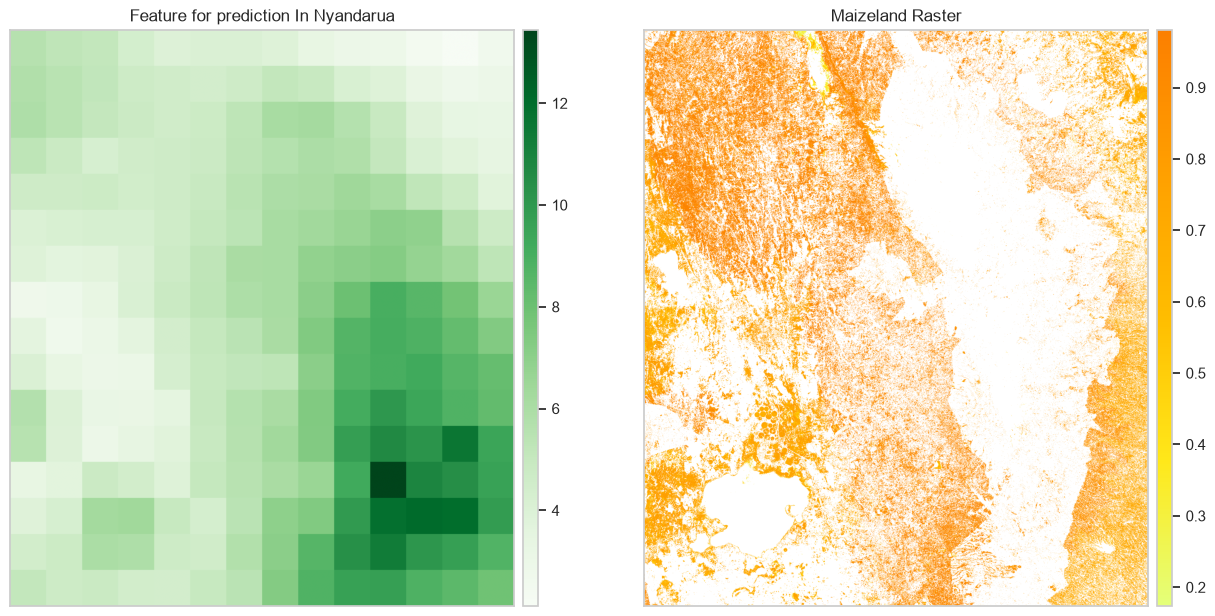

In [91]:
import rasterio
from rasterio.plot import show, plotting_extent
import earthpy as et
import earthpy.plot as ep 

f, (ax1,ax2) = plt.subplots(1,2,figsize=(15,8))
ep.plot_bands(feature_map.read(1),cmap='Greens',ax=ax1)
ax1.set_title('Feature for prediction In Nyandarua')
ep.plot_bands(maizeland_raster.read(1),cmap='Wistia',ax=ax2)
ax2.set_title('Maizeland Raster')

In [1]:
crop_mask = (
    ee.ImageCollection("USGS/GFSAD1000_V1")
    .filterBounds(aoi)
    .select("landcover")
)

crop_mask

NameError: name 'ee' is not defined

In [ ]:
# export to 

## Post Processing with Crop Land Mask and Probability Threshold

In [ ]:
import earthpy.mask as em  

f, (ax1,ax2) = plt.subplots(1,2,figsize=(15,8))

# create separate array of true/false values for pixels above/below 40 percent threshold
cropland_mask = cropland_raster.read(1) < 40
# use true/false array to remove all pixels which were below 40 percent
cropland_masked = em.mask_pixels(cropland_raster.read(1), cropland_mask)

# remove all pixels from maizeland raster which do not contain crops
maizeland_crop_masked = em.mask_pixels(maizeland_raster.read(1), cropland_mask)

# create array of remaining maizeland pixels as either above/below the 60 percent threshold
maizeland_mask = maizeland_crop_masked < 60
# remove all maizeland pixels which were below 60 percent
maizeland_masked = em.mask_pixels(maizeland_crop_masked, maizeland_mask)

# plot final rasters identifying cropland and maizeland predicted from models
ep.plot_bands(cropland_masked,cmap='Greens',ax=ax1,scale=True,vmin=0,vmax=100)
ep.plot_bands(maizeland_masked,cmap='Wistia',ax=ax2,scale=True,vmin=0,vmax=100)